In [63]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Loading the dataset
df = pd.read_csv("lendingclub_raw.csv", low_memory=False)

In [3]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.shape

(2260701, 151)

In [5]:
df.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='object', length=151)

In [6]:
# To clearly see all column names - storing in a list.
lst = df.columns.tolist()
lst

['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'last_fico_range_high',
 'last_fico_range_low',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 '

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 2.5+ GB


In [8]:
# For business analysis, borrower profile and loan details are needed.
columns_needed = ["loan_amnt",
                  "term",
                  "int_rate",
                  "grade",
                  "emp_length",
                  "home_ownership",
                  "annual_inc",
                  "loan_status",
                  "purpose",
                  "dti",
                  "fico_range_low",
                  "fico_range_high"]

In [9]:
# Analysis to be done in a dataframe with selective columns & their data
df = df[columns_needed].copy()

In [157]:
# After selecting relevant loan and borrower attributes, Exploratory checks are to be performed using info(), describe(),
# and null analysis to understand data quality, distributions, and required cleaning steps.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 658974 entries, 0 to 658973
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   loan_amnt        658968 non-null  float64
 1   term             658968 non-null  object 
 2   int_rate         658968 non-null  float64
 3   grade            658968 non-null  object 
 4   emp_length       616717 non-null  object 
 5   home_ownership   658968 non-null  object 
 6   annual_inc       658968 non-null  float64
 7   loan_status      658967 non-null  object 
 8   purpose          658967 non-null  object 
 9   dti              658519 non-null  float64
 10  fico_range_low   658967 non-null  float64
 11  fico_range_high  658967 non-null  float64
dtypes: float64(6), object(6)
memory usage: 60.3+ MB


In [10]:
df.describe()

,loan_amnt,int_rate,annual_inc,dti,fico_range_low,fico_range_high
count,2.260668e+06,2.260668e+06,2.260664e+06,2.258957e+06,2.260668e+06,2.260668e+06
mean,1.504693e+04,1.309283e+01,7.799243e+04,1.882420e+01,6.985882e+02,7.025884e+02
std,9.190245e+03,4.832138e+00,1.126962e+05,1.418333e+01,3.301038e+01,3.301124e+01
min,5.000000e+02,5.310000e+00,0.000000e+00,-1.000000e+00,6.100000e+02,6.140000e+02
25%,8.000000e+03,9.490000e+00,4.600000e+04,1.189000e+01,6.750000e+02,6.790000e+02
50%,1.290000e+04,1.262000e+01,6.500000e+04,1.784000e+01,6.900000e+02,6.940000e+02
75%,2.000000e+04,1.599000e+01,9.300000e+04,2.449000e+01,7.150000e+02,7.190000e+02
max,4.000000e+04,3.099000e+01,1.100000e+08,9.990000e+02,8.450000e+02,8.500000e+02


In [11]:
df.isnull().sum()

loan_amnt              33
term                   33
int_rate               33
grade                  33
emp_length         146940
home_ownership         33
annual_inc             37
loan_status            33
purpose                33
dti                  1744
fico_range_low         33
fico_range_high        33
dtype: int64

In [160]:
df.head()

,loan_amnt,term,int_rate,grade,emp_length,home_ownership,annual_inc,loan_status,purpose,dti,fico_range_low,fico_range_high
0,3600.0,36 months,13.99,C,10+ years,MORTGAGE,55000.0,Fully Paid,debt_consolidation,5.91,675.0,679.0
1,24700.0,36 months,11.99,C,10+ years,MORTGAGE,65000.0,Fully Paid,small_business,16.06,715.0,719.0
2,20000.0,60 months,10.78,B,10+ years,MORTGAGE,63000.0,Fully Paid,home_improvement,10.78,695.0,699.0
3,35000.0,60 months,14.85,C,10+ years,MORTGAGE,110000.0,Current,debt_consolidation,17.06,785.0,789.0
4,10400.0,60 months,22.45,F,3 years,MORTGAGE,104433.0,Fully Paid,major_purchase,25.37,695.0,699.0


In [12]:
# Dropping the duplicate rows
df.drop_duplicates()

,loan_amnt,term,int_rate,grade,emp_length,home_ownership,annual_inc,loan_status,purpose,dti,fico_range_low,fico_range_high
0,3600.0,36 months,13.99,C,10+ years,MORTGAGE,55000.0,Fully Paid,debt_consolidation,5.91,675.0,679.0
1,24700.0,36 months,11.99,C,10+ years,MORTGAGE,65000.0,Fully Paid,small_business,16.06,715.0,719.0
2,20000.0,60 months,10.78,B,10+ years,MORTGAGE,63000.0,Fully Paid,home_improvement,10.78,695.0,699.0
3,35000.0,60 months,14.85,C,10+ years,MORTGAGE,110000.0,Current,debt_consolidation,17.06,785.0,789.0
4,10400.0,60 months,22.45,F,3 years,MORTGAGE,104433.0,Fully Paid,major_purchase,25.37,695.0,699.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2260694,24000.0,60 months,12.79,C,7 years,MORTGAGE,95000.0,Current,home_improvement,19.61,665.0,669.0
2260695,24000.0,60 months,10.49,B,10+ years,MORTGAGE,108000.0,Current,debt_consolidation,34.94,695.0,699.0
2260696,40000.0,60 months,10.49,B,9 years,MORTGAGE,227000.0,Current,debt_consolidation,12.75,705.0,709.0
2260697,24000.0,60 months,14.49,C,6 years,RENT,110000.0,Charged Off,debt_consolidation,18.30,660.0,664.0


In [13]:
# 1st Attribute -> Loan Amount
df["loan_amnt"].isnull().sum()

np.int64(33)

In [14]:
# There are many null values in loan amount & since it's a critical data we require for analysyis - dropping the null rows
df=df.dropna(subset=["loan_amnt"])

In [15]:
df.isnull().sum()
# Many null value rows got removed with it.

loan_amnt               0
term                    0
int_rate                0
grade                   0
emp_length         146907
home_ownership          0
annual_inc              4
loan_status             0
purpose                 0
dti                  1711
fico_range_low          0
fico_range_high         0
dtype: int64

In [16]:
# 2nd Attribute -> Term
df.term.unique()

array([' 36 months', ' 60 months'], dtype=object)

In [17]:
# Remove uneccessary space
df["term"] = df["term"].str.strip()

In [18]:
# Remove months string from data
df["term"] = df["term"].str.replace(" months","").astype(int)

In [19]:
# Rename the term attribute
df = df.rename(columns={"term":"term_in_months"})

In [20]:
df["term_in_months"].unique()

array([36, 60])

In [28]:
# 3rd Attribute -> Interest rate
df["int_rate"].unique()

array([13.99, 11.99, 10.78, 14.85, 22.45, 13.44,  9.17,  8.49,  6.49,
       11.48, 12.88, 19.48,  7.49, 19.89,  5.32, 17.97, 24.24, 15.77,
        9.8 , 20.5 , 17.27, 16.59, 18.49,  7.91, 23.13, 18.99, 26.06,
       21.48,  6.99, 27.49, 26.99, 27.99, 28.49,  6.  , 25.09, 28.99,
       16.55,  7.89, 12.59, 13.67, 10.64,  7.26, 17.86, 13.18, 14.48,
       18.2 ,  6.24,  8.38, 15.41,  9.76, 21.99, 16.99, 25.99, 17.57,
       22.99, 20.99,  6.89, 11.22, 19.99, 27.31, 27.88, 23.99, 24.99,
       26.77, 14.33, 12.05,  8.18,  9.99, 11.49, 10.99, 16.9 , 11.53,
       18.55, 14.65, 13.33, 12.69, 18.25, 19.19, 12.29, 15.61, 25.78,
       19.52, 24.5 ,  6.39,  5.93, 21.67,  6.92,  6.68, 20.49, 25.8 ,
       18.84, 25.57, 25.83, 25.89,  8.67, 14.99, 17.14,  8.19, 10.49,
       11.44,  6.03, 15.59, 12.39,  9.49, 13.66, 14.31, 12.99, 15.99,
       16.49, 19.24, 18.54, 20.39,  9.92, 30.79, 21.85,  7.34, 10.41,
       17.47,  6.07, 12.61, 13.58,  9.43, 18.45, 11.98,  7.96,  6.71,
        5.31, 15.04,

In [29]:
# 4th Attribute -> Grade
df.grade.unique()

array(['C', 'B', 'F', 'A', 'E', 'D', 'G'], dtype=object)

In [32]:
# 5th Attribute -> Employee Length
df["emp_length"].isna().sum()

np.int64(0)

In [31]:
df["emp_length"] = df["emp_length"].fillna("Unknown")

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2260668 entries, 0 to 2260698
Data columns (total 12 columns):
 #   Column           Dtype  
---  ------           -----  
 0   loan_amnt        float64
 1   term_in_months   int64  
 2   int_rate         float64
 3   grade            object 
 4   emp_length       object 
 5   home_ownership   object 
 6   annual_inc       float64
 7   loan_status      object 
 8   purpose          object 
 9   dti              float64
 10  fico_range_low   float64
 11  fico_range_high  float64
dtypes: float64(6), int64(1), object(5)
memory usage: 224.2+ MB


In [34]:
# 6th Attribute -> Home Ownership
df["home_ownership"].unique()

array(['MORTGAGE', 'RENT', 'OWN', 'ANY', 'NONE', 'OTHER'], dtype=object)

In [35]:
# 7th Attribute -> Annual Income
df["annual_inc"].unique()

array([ 55000.,  65000.,  63000., ..., 101303., 131209., 180792.])

In [45]:
df["annual_inc"].isnull().sum()

np.int64(4)

In [46]:
df["annual_inc"] = df["annual_inc"].fillna(df["annual_inc"].median())

In [36]:
# 8th Attribute -> Loan Status
df["loan_status"].unique()

array(['Fully Paid', 'Current', 'Charged Off', 'In Grace Period',
       'Late (31-120 days)', 'Late (16-30 days)', 'Default',
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

In [37]:
df["loan_status"].value_counts()

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

In [38]:
# When applying for a loan, the system usually decides whether to accept it or reject it.
df["decision"] = df["loan_status"].apply(lambda x: "Approved" if x in ["Fully Paid", "Current"] else "Rejected")

In [39]:
df["decision"].value_counts()

decision
Approved    1955068
Rejected     305600
Name: count, dtype: int64

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2260668 entries, 0 to 2260698
Data columns (total 13 columns):
 #   Column           Dtype  
---  ------           -----  
 0   loan_amnt        float64
 1   term_in_months   int64  
 2   int_rate         float64
 3   grade            object 
 4   emp_length       object 
 5   home_ownership   object 
 6   annual_inc       float64
 7   loan_status      object 
 8   purpose          object 
 9   dti              float64
 10  fico_range_low   float64
 11  fico_range_high  float64
 12  decision         object 
dtypes: float64(6), int64(1), object(6)
memory usage: 241.5+ MB


In [41]:
# 9th Attribute -> Purpose
df["purpose"].unique()

array(['debt_consolidation', 'small_business', 'home_improvement',
       'major_purchase', 'credit_card', 'other', 'house', 'vacation',
       'car', 'medical', 'moving', 'renewable_energy', 'wedding',
       'educational'], dtype=object)

In [42]:
# 10th Attribute -> DTI
df["dti"].isnull().sum()

np.int64(1711)

In [43]:
df["dti"]=df["dti"].fillna(df["dti"].median())

In [53]:
df.dti.unique()

array([  5.91,  16.06,  10.78, ...,  95.83, 172.14, 250.72])

In [176]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 658968 entries, 0 to 658973
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   loan_amnt        658968 non-null  float64
 1   term_in_months   658968 non-null  int64  
 2   int_rate         658968 non-null  float64
 3   grade            658968 non-null  object 
 4   emp_length       658968 non-null  object 
 5   home_ownership   658968 non-null  object 
 6   annual_inc       658968 non-null  float64
 7   loan_status      658967 non-null  object 
 8   purpose          658967 non-null  object 
 9   dti              658968 non-null  float64
 10  fico_range_low   658967 non-null  float64
 11  fico_range_high  658967 non-null  float64
 12  decision         658968 non-null  object 
dtypes: float64(6), int64(1), object(6)
memory usage: 70.4+ MB


In [47]:
df.isna().sum()

loan_amnt          0
term_in_months     0
int_rate           0
grade              0
emp_length         0
home_ownership     0
annual_inc         0
loan_status        0
purpose            0
dti                0
fico_range_low     0
fico_range_high    0
decision           0
dtype: int64

In [55]:
# Creating Credit Score
df["credit_score"] = (df["fico_range_low"] + df["fico_range_high"]) / 2

In [56]:
df["credit_score"].describe()

count    2.260668e+06
mean     7.005883e+02
std      3.301081e+01
min      6.120000e+02
25%      6.770000e+02
50%      6.920000e+02
75%      7.170000e+02
max      8.475000e+02
Name: credit_score, dtype: float64

In [57]:
# Creating Risk Segment
df["risk_segment"] = df.apply(lambda x: "Low Risk" if (x["credit_score"] >= 700) or (x["dti"] < 25) else "High Risk", axis = 1)

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2260668 entries, 0 to 2260698
Data columns (total 15 columns):
 #   Column           Dtype  
---  ------           -----  
 0   loan_amnt        float64
 1   term_in_months   int64  
 2   int_rate         float64
 3   grade            object 
 4   emp_length       object 
 5   home_ownership   object 
 6   annual_inc       float64
 7   loan_status      object 
 8   purpose          object 
 9   dti              float64
 10  fico_range_low   float64
 11  fico_range_high  float64
 12  decision         object 
 13  credit_score     float64
 14  risk_segment     object 
dtypes: float64(7), int64(1), object(7)
memory usage: 276.0+ MB


In [59]:
df.head()

,loan_amnt,term_in_months,int_rate,grade,emp_length,home_ownership,annual_inc,loan_status,purpose,dti,fico_range_low,fico_range_high,decision,credit_score,risk_segment
0,3600.0,36,13.99,C,10+ years,MORTGAGE,55000.0,Fully Paid,debt_consolidation,5.91,675.0,679.0,Approved,677.0,Low Risk
1,24700.0,36,11.99,C,10+ years,MORTGAGE,65000.0,Fully Paid,small_business,16.06,715.0,719.0,Approved,717.0,Low Risk
2,20000.0,60,10.78,B,10+ years,MORTGAGE,63000.0,Fully Paid,home_improvement,10.78,695.0,699.0,Approved,697.0,Low Risk
3,35000.0,60,14.85,C,10+ years,MORTGAGE,110000.0,Current,debt_consolidation,17.06,785.0,789.0,Approved,787.0,Low Risk
4,10400.0,60,22.45,F,3 years,MORTGAGE,104433.0,Fully Paid,major_purchase,25.37,695.0,699.0,Approved,697.0,High Risk


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2260668 entries, 0 to 2260698
Data columns (total 15 columns):
 #   Column           Dtype  
---  ------           -----  
 0   loan_amnt        float64
 1   term_in_months   int64  
 2   int_rate         float64
 3   grade            object 
 4   emp_length       object 
 5   home_ownership   object 
 6   annual_inc       float64
 7   loan_status      object 
 8   purpose          object 
 9   dti              float64
 10  fico_range_low   float64
 11  fico_range_high  float64
 12  decision         object 
 13  credit_score     float64
 14  risk_segment     object 
dtypes: float64(7), int64(1), object(7)
memory usage: 276.0+ MB


# Analysis

1. Overall Loan Approval Rate

In [61]:
df["decision"].value_counts(normalize=True)*100

decision
Approved    86.481872
Rejected    13.518128
Name: proportion, dtype: float64

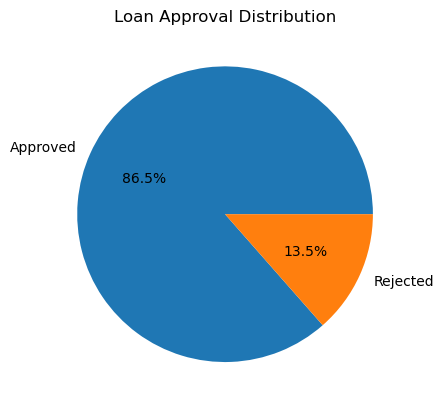

In [67]:
approval_counts = df["decision"].value_counts()

plt.figure()
plt.pie(approval_counts, labels=approval_counts.index, autopct='%1.1f%%')
plt.title("Loan Approval Distribution")

plt.show()

The analysis of the loan approval rate shows that the platform approves 86.5% of applications, indicating its overall approach.

2. Factors Drive Approval

In [68]:
# Credit Score Affect Approval
df.groupby(df["decision"])["credit_score"].mean()

decision
Approved    702.194556
Rejected    690.312335
Name: credit_score, dtype: float64

Credit score alone does not significantly differentiate approved and rejected (or risky) borrowers, indicating that lending decisions and loan outcomes depend on multiple factors beyond credit score.

In [69]:
#Let's check the distribution
df.groupby("decision")["credit_score"].describe()

,count,mean,std,min,25%,50%,75%,max
decision,,,,,,,,
Approved,1955068.0,702.194556,33.646966,627.0,677.0,697.0,722.0,847.5
Rejected,305600.0,690.312335,26.388092,612.0,672.0,682.0,702.0,847.5


While credit score is an important factor, it alone does not guarantee loan success. Some high-credit borrowers still fall into risky segments, indicating the need for multi-factor risk assessment.

In [70]:
# Loan Approval Rate based on Credit Score, DTI, Annual Income
df.groupby("decision")[["credit_score","dti","annual_inc"]].mean()

,credit_score,dti,annual_inc
decision,,,
Approved,702.194556,18.621526,79038.279595
Rejected,690.312335,20.115266,71301.454827


Approval decisions are influenced by a combination of credit score, income, and debt levels rather than a single factor.